In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_loader import get_prices
from src.walk_forward import walk_forward_backtest

In [3]:
tickers = ["AAPL", "TSLA", "SPY"]
prices = get_prices(tickers)

returns, weights = walk_forward_backtest(
    prices,
    train_window=120,
    test_window=21,
    rebalance_freq=21,
    transaction_cost=0.001
)

[*********************100%***********************]  3 of 3 completed


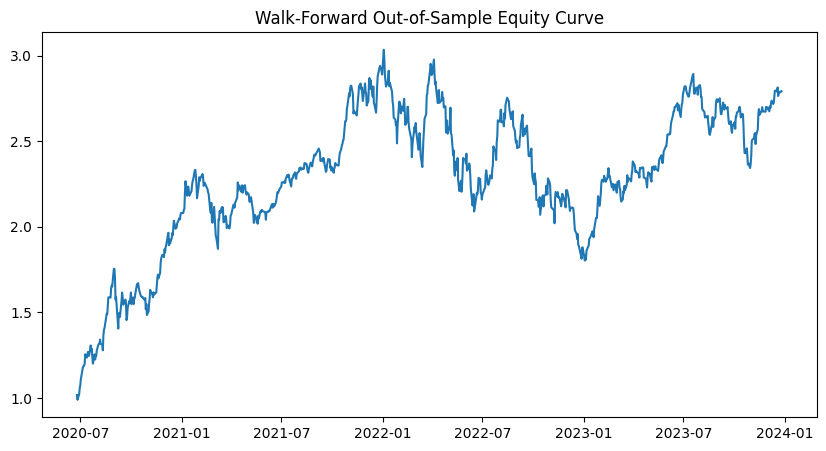

In [4]:
import matplotlib.pyplot as plt

cumulative = (1 + returns).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cumulative)
plt.title("Walk-Forward Out-of-Sample Equity Curve")
plt.show()

In [5]:
def sharpe(r):
    return r.mean() / r.std()

def max_drawdown(r):
    cum = (1 + r).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()


print("OOS Sharpe:", sharpe(returns))
print("OOS Max Drawdown:", max_drawdown(returns))
print("OOS Mean Return:", returns.mean())

OOS Sharpe: 0.06826387849051742
OOS Max Drawdown: -0.4059229672028567
OOS Mean Return: 0.0013659065948771465
